# Libraries

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import shapiro

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose

# Load Data

In [2]:
df_jatim_raw = pd.read_csv("dataset/Data_Jatim.csv")
df_jatim_raw["Tanggal"] = pd.to_datetime(df_jatim_raw["Tanggal"])
df_jatim_raw["Inflasi"] = pd.to_numeric(df_jatim_raw["Inflasi"], errors="coerce")

display(df_jatim_raw.head())

,Tanggal,KOTA,Inflasi
0,2015-01-01,BANYUWANGI,0.08
1,2015-02-01,BANYUWANGI,-1.02
2,2015-03-01,BANYUWANGI,0.09
3,2015-04-01,BANYUWANGI,0.36
4,2015-05-01,BANYUWANGI,0.55


# Data Information

In [3]:
df_jatim = (df_jatim_raw.groupby("Tanggal")["Inflasi"]
            .mean().reset_index()
            .rename(columns={
                "Tanggal": "tanggal",
                "Inflasi": "inflasi"
            }).set_index("tanggal").sort_index().asfreq("MS"))

df_jatim = df_jatim.loc["2015-01-01":"2025-12-01"]
display(df_jatim.head())

,inflasi
tanggal,
2015-01-01,-0.05250
2015-02-01,-0.60875
2015-03-01,0.23125
2015-04-01,0.31750
2015-05-01,0.40250


# Exploratory Data Analysis

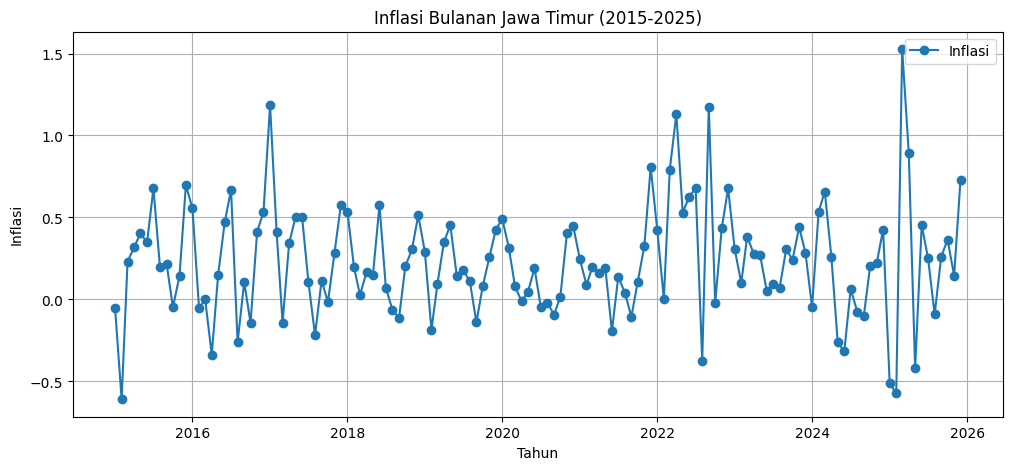

In [4]:
plt.figure(figsize=(12,5))
plt.plot(df_jatim.index, df_jatim["inflasi"], marker="o", label="Inflasi")
plt.title("Inflasi Bulanan Jawa Timur (2015-2025)")
plt.xlabel("Tahun")
plt.ylabel("Inflasi")
plt.grid(True)
plt.legend()
plt.show()

## Rolling Mean and Standard Deviation

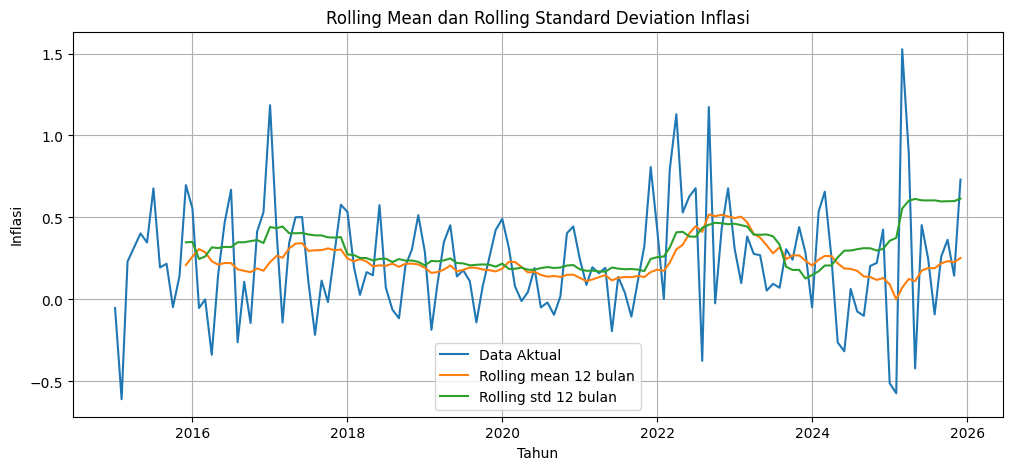

In [5]:
rolling_mean = df_jatim["inflasi"].rolling(window=12).mean()
rolling_std = df_jatim["inflasi"].rolling(window=12).std()

plt.figure(figsize=(12, 5))
plt.plot(df_jatim.index, df_jatim["inflasi"], label="Data Aktual")
plt.plot(rolling_mean.index, rolling_mean, label="Rolling mean 12 bulan")
plt.plot(rolling_std.index, rolling_std, label="Rolling std 12 bulan")

plt.title("Rolling Mean dan Rolling Standard Deviation Inflasi")
plt.xlabel("Tahun")
plt.ylabel("Inflasi")
plt.legend()
plt.grid(True)
plt.show()

## Seasonal Decomposition

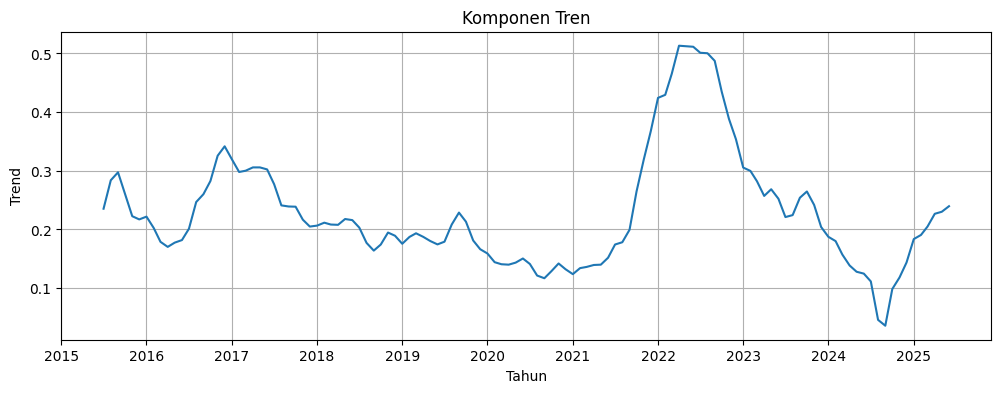

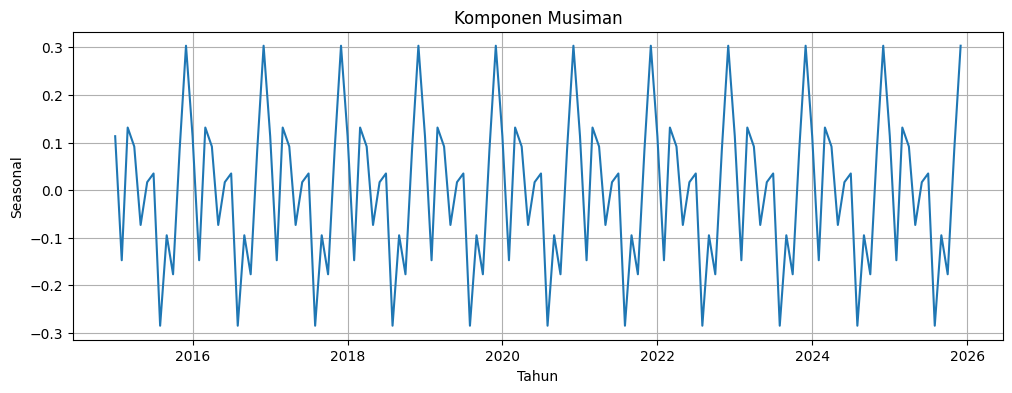

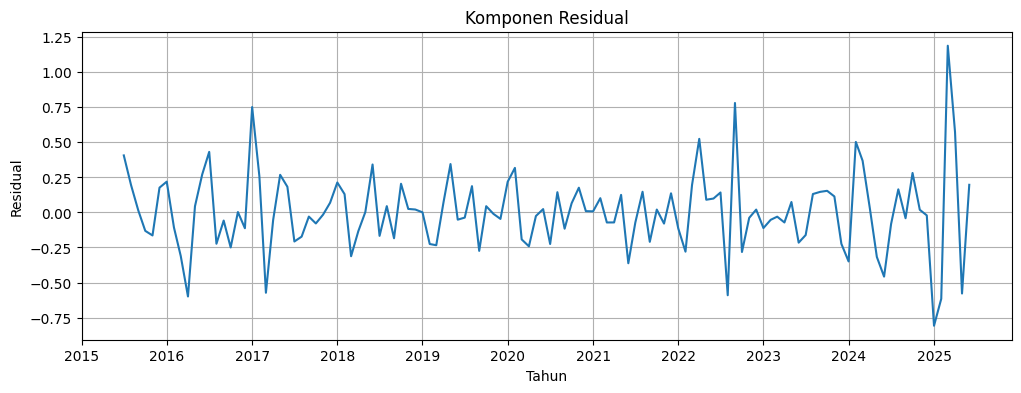

In [6]:
decomposition = seasonal_decompose(
    df_jatim["inflasi"],
    model="additive",
    period=12
)

plt.figure(figsize=(12, 4))
plt.plot(decomposition.trend)
plt.title("Komponen Tren")
plt.xlabel("Tahun")
plt.ylabel("Trend")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(decomposition.seasonal)
plt.title("Komponen Musiman")
plt.xlabel("Tahun")
plt.ylabel("Seasonal")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(decomposition.resid)
plt.title("Komponen Residual")
plt.xlabel("Tahun")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

## Train-Test Split

In [7]:
y = df_jatim["inflasi"]
df_train = y.loc["2015-01-01":"2024-12-01"]
df_test = y.loc["2025-01-01":"2025-12-01"]

print("Jumlah train:", len(df_train))
print("Jumlah test:", len(df_test))
print("Periode train:", df_train.index.min(), "-", df_train.index.max())
print("Periode test:", df_test.index.min(), "-", df_test.index.max())

Jumlah train: 120
Jumlah test: 12
Periode train: 2015-01-01 00:00:00 - 2024-12-01 00:00:00
Periode test: 2025-01-01 00:00:00 - 2025-12-01 00:00:00


# Stationarity Test

In [8]:
def adf_test(data, name="Data"):
    result = adfuller(data.dropna())
    print(f"ADF Test - {name}")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value}")
    
    if result[1] < 0.05:
        print("Kesimpulan: stasioner")
    else:
        print("Kesimpulan: belum stationer")
    print("-" * 60)

adf_test(df_train, "Data Train")
adf_test(df_train.diff().dropna(), "Differencing Regular d=1")
adf_test(df_train.diff(12).dropna(), "Differencing Musiman D=1")
adf_test(df_train.diff().diff(12).dropna(), "Differencing Regular d=1 dan Musiman D=1")

ADF Test - Data Train
ADF Statistic: -8.500255252188524
p-value: 1.2438658564066826e-13
Critical Values:
1%: -3.4865346059036564
5%: -2.8861509858476264
10%: -2.579896092790057
Kesimpulan: stasioner
------------------------------------------------------------
ADF Test - Differencing Regular d=1
ADF Statistic: -6.471479217651011
p-value: 1.3637256722162853e-08
Critical Values:
1%: -3.4924012594942333
5%: -2.8886968193364835
10%: -2.5812552709190673
Kesimpulan: stasioner
------------------------------------------------------------
ADF Test - Differencing Musiman D=1
ADF Statistic: -3.6159323619914296
p-value: 0.005463639471734951
Critical Values:
1%: -3.5003788874873405
5%: -2.8921519665075235
10%: -2.5830997960069446
Kesimpulan: stasioner
------------------------------------------------------------
ADF Test - Differencing Regular d=1 dan Musiman D=1
ADF Statistic: -4.685276676739766
p-value: 8.967856621905304e-05
Critical Values:
1%: -3.5019123847798657
5%: -2.892815255482889
10%: -2.58

# ACF and PACF

In [9]:
train = df_train.dropna()
train_d1 = df_train.diff().dropna()
train_D1 = df_train.diff(12).dropna()
train_d1_D1 = df_train.diff().diff(12).dropna()

In [10]:
def plot_acf_pacf(series, title, lags=36):
    plt.figure(figsize=(10, 4))
    plot_acf(series, lags=lags)
    plt.title(f"ACF - {title}")
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.show()

    plt.figure(figsize=(10, 4))
    plot_pacf(series, lags=lags, method="ywm")
    plt.title(f"PACF - {title}")
    plt.xlabel("Lag")
    plt.ylabel("Partial Autocorrelation")
    plt.show()

<Figure size 1000x400 with 0 Axes>

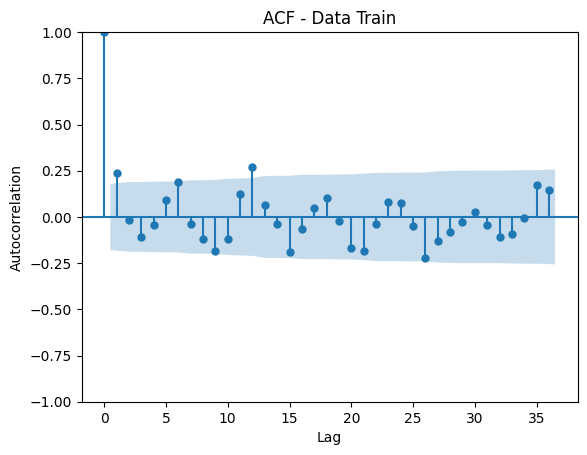

<Figure size 1000x400 with 0 Axes>

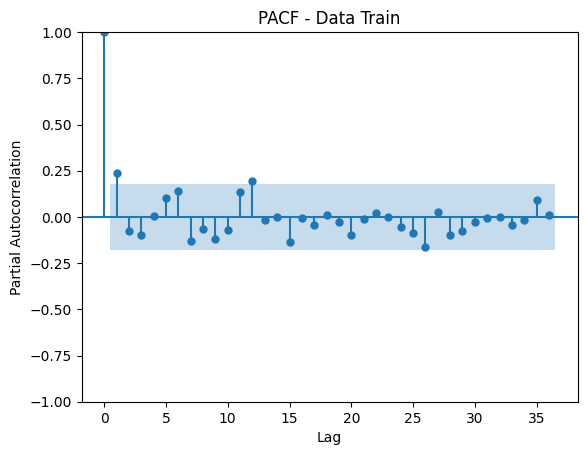

<Figure size 1000x400 with 0 Axes>

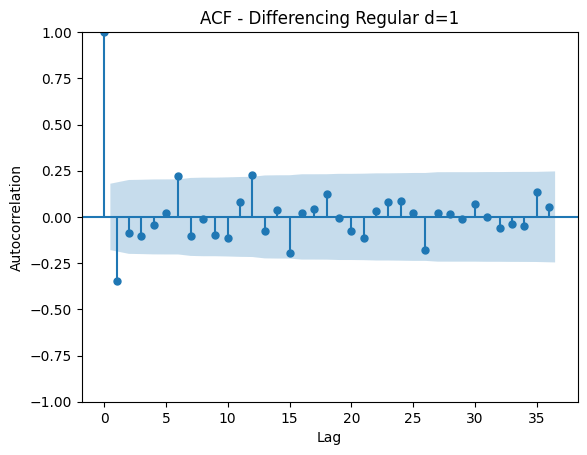

<Figure size 1000x400 with 0 Axes>

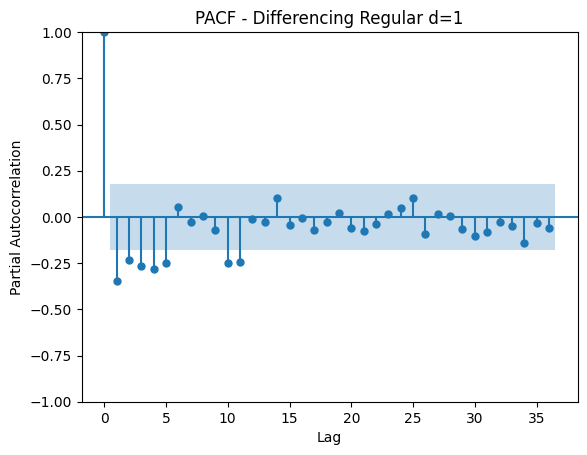

<Figure size 1000x400 with 0 Axes>

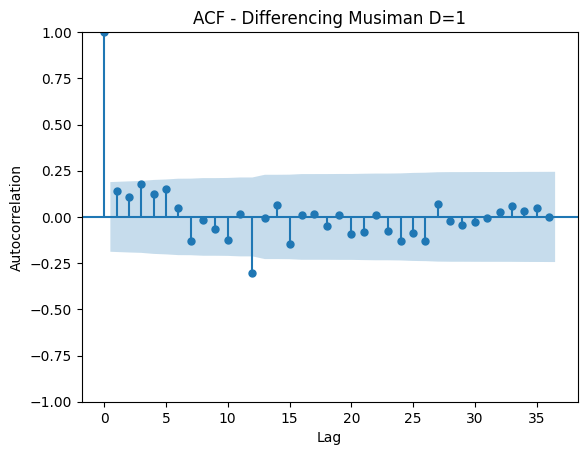

<Figure size 1000x400 with 0 Axes>

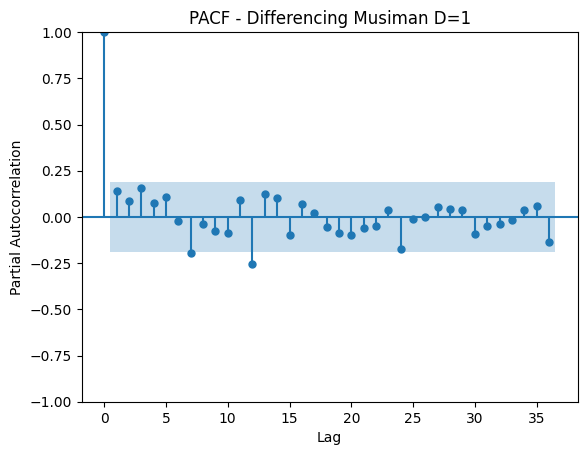

<Figure size 1000x400 with 0 Axes>

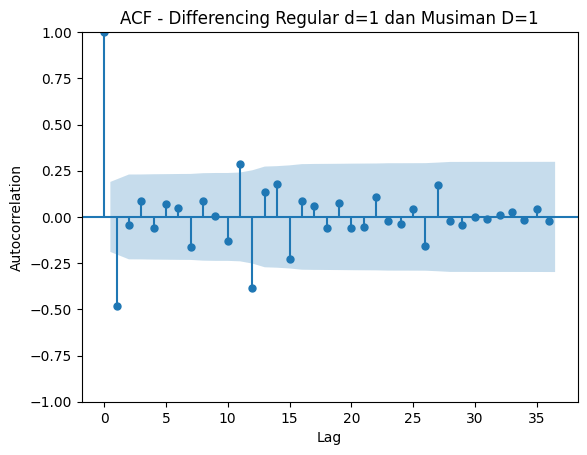

<Figure size 1000x400 with 0 Axes>

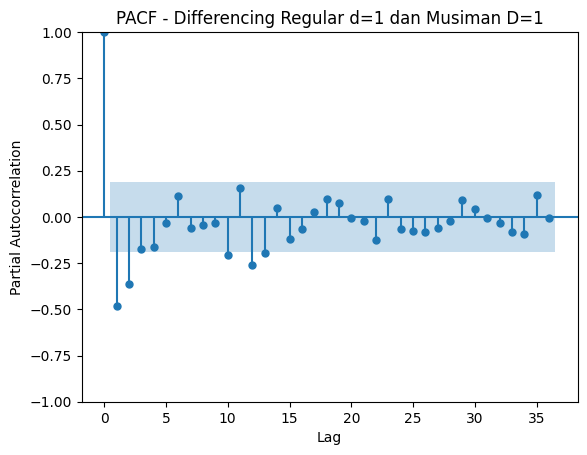

In [11]:
plot_acf_pacf(train, "Data Train", lags=36)
plot_acf_pacf(train_d1, "Differencing Regular d=1", lags=36)
plot_acf_pacf(train_D1, "Differencing Musiman D=1", lags=36)
plot_acf_pacf(train_d1_D1, "Differencing Regular d=1 dan Musiman D=1", lags=36)

# SARIMA Model Estimation

In [12]:
s = 12

results = []

p_values = range(0,3)
d_values = range(0,2)
q_values = range(0,3)

P_values = range(0, 2)
D_values = range(0, 2)
Q_values = range(0, 2)

for p in p_values:
    for d in d_values:
        for q in q_values:
            for P in P_values:
                for D in D_values:
                    for Q in Q_values:
                        order = (p,d,q)
                        seasonal_order = (P,D,Q,s)
                        if order == (0,0,0) and seasonal_order == (0,0,0,s):
                            continue
                        try:
                            model = SARIMAX(
                                df_train,
                                order=order,
                                seasonal_order=seasonal_order,
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )
                            fitted = model.fit(disp=False, maxiter=300)
                            forecast_test = fitted.get_forecast(steps=len(df_test))
                            pred_test = forecast_test.predicted_mean
                            pred_test.index = df_test.index

                            rmse = np.sqrt(mean_squared_error(df_test, pred_test))
                            mae = mean_absolute_error(df_test, pred_test)

                            lb_test = acorr_ljungbox(
                                fitted.resid.dropna(),
                                lags=[12],
                                return_df=True
                            )
                            lb_pvalue = lb_test["lb_pvalue"].iloc[0]
                            shapiro_pvalue = shapiro(fitted.resid.dropna()).pvalue

                            results.append({
                                "order": order,
                                "seasonal_order": seasonal_order,
                                "aic": fitted.aic,
                                "bic": fitted.bic,
                                "rmse": rmse,
                                "mae": mae,
                                "ljungbox_pvalue": lb_pvalue,
                                "shapiro_pvalue": shapiro_pvalue
                            })
                        except Exception as e:
                            pass

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(["aic", "rmse"]).reset_index(drop=True)
print("Top model berdasarkan AIC:")
display(df_results.head(10))

C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Top model berdasarkan AIC:


,order,seasonal_order,aic,bic,rmse,mae,ljungbox_pvalue,shapiro_pvalue
0,"(1, 0, 2)","(1, 0, 1, 12)",39.205684,55.129447,0.563709,0.452436,0.736549,0.010489
1,"(1, 1, 2)","(1, 0, 1, 12)",39.849753,55.716098,0.571522,0.455754,0.645708,0.029193
2,"(0, 1, 2)","(1, 0, 1, 12)",40.096062,53.318017,0.572875,0.456579,0.864174,0.011673
3,"(0, 1, 1)","(1, 0, 1, 12)",41.047217,51.663058,0.570598,0.455594,0.878149,0.010483
4,"(2, 0, 2)","(1, 0, 1, 12)",41.078752,59.656474,0.566060,0.453871,0.738557,0.011577
5,"(2, 1, 2)","(1, 0, 1, 12)",41.721753,60.232489,0.569449,0.454626,0.597243,0.028567
6,"(1, 0, 1)","(1, 0, 1, 12)",41.760630,55.077825,0.572743,0.459654,0.889671,0.006539
7,"(1, 1, 1)","(1, 0, 1, 12)",42.055769,55.325571,0.571832,0.455279,0.913525,0.003054
8,"(0, 0, 1)","(0, 1, 1, 12)",42.103978,49.733862,0.535081,0.417507,0.299036,0.003047
9,"(1, 0, 1)","(0, 1, 1, 12)",42.296478,52.469657,0.518718,0.410355,0.601421,0.017217


In [13]:
df_results.to_csv("top_model_sarima_jatim.csv", index=False)

models = df_results[
    (df_results["ljungbox_pvalue"] > 0.05) & (df_results["shapiro_pvalue"] > 0.05)
].copy()

print(f"Jumlah model yang lolos diagnostic checking: {len(models)}")
if len(models) > 0:
    best_model = models.sort_values(["rmse", "aic"]).iloc[0]
else:
    best_model = df_results.iloc[0]

print("Model SARIMA terbaik")
print(best_model)

Jumlah model yang lolos diagnostic checking: 26
Model SARIMA terbaik
order                  (2, 1, 2)
seasonal_order     (1, 1, 1, 12)
aic                    53.013745
bic                    70.666265
rmse                    0.470379
mae                     0.371399
ljungbox_pvalue         0.295008
shapiro_pvalue          0.309776
Name: 60, dtype: object


# Fit Model

In [14]:
best_order = best_model["order"]
best_seasonal_order = best_model["seasonal_order"]

best_model_train = SARIMAX(
    df_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_fitted_train = best_model_train.fit(disp=False, maxiter=300)
print(best_fitted_train.summary())

                                      SARIMAX Results                                       
Dep. Variable:                              inflasi   No. Observations:                  120
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                 -19.507
Date:                              Thu, 25 Jun 2026   AIC                             53.014
Time:                                      17:46:56   BIC                             70.666
Sample:                                  01-01-2015   HQIC                            60.138
                                       - 12-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7948      0.102      7.759      0.000       0.594       0.996
ar.L2         -0.30

# Evaluasi out-sample

In [15]:
forecast_test = best_fitted_train.get_forecast(steps=len(df_test))
pred_test = forecast_test.predicted_mean
pred_test.index = df_test.index

df_eval = pd.DataFrame({
    "actual": df_test,
    "forecast": pred_test
})
df_eval["error"] = df_eval["actual"] - df_eval["forecast"]
df_eval["abs_error"] = df_eval["error"].abs()
df_eval["squared_error"] = df_eval["error"] ** 2

rmse = np.sqrt(mean_squared_error(df_eval["actual"], df_eval["forecast"]))
mae = mean_absolute_error(df_eval["actual"], df_eval["forecast"])

display(df_eval)
print("RMSE:", rmse)
print("MAE :", mae)

df_eval.to_csv("evaluasi_outsample_2025_jatim.csv")

,actual,forecast,error,abs_error,squared_error
tanggal,,,,,
2025-01-01,-0.51125,0.010852,-0.522102,0.522102,0.272590
2025-02-01,-0.57250,0.100444,-0.672944,0.672944,0.452854
2025-03-01,1.52625,0.519661,1.006589,1.006589,1.013222
2025-04-01,0.89250,0.530759,0.361741,0.361741,0.130856
2025-05-01,-0.42125,0.317298,-0.738548,0.738548,0.545454
2025-06-01,0.45375,0.210310,0.243440,0.243440,0.059263
2025-07-01,0.25125,0.324221,-0.072971,0.072971,0.005325
2025-08-01,-0.09125,0.054882,-0.146132,0.146132,0.021355
2025-09-01,0.26125,0.380699,-0.119449,0.119449,0.014268


RMSE: 0.4703794654623188
MAE : 0.3713991631899252


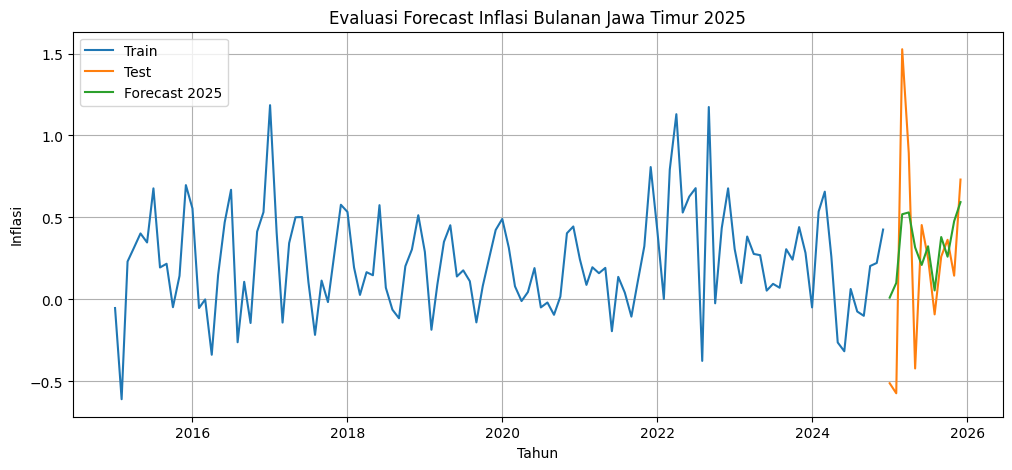

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(df_train.index, df_train, label="Train")
plt.plot(df_test.index, df_test, label="Test")
plt.plot(pred_test.index, pred_test, label="Forecast 2025")
plt.title("Evaluasi Forecast Inflasi Bulanan Jawa Timur 2025")
plt.xlabel("Tahun")
plt.ylabel("Inflasi")
plt.legend()
plt.grid(True)
plt.show()

# Diagnostic Checking

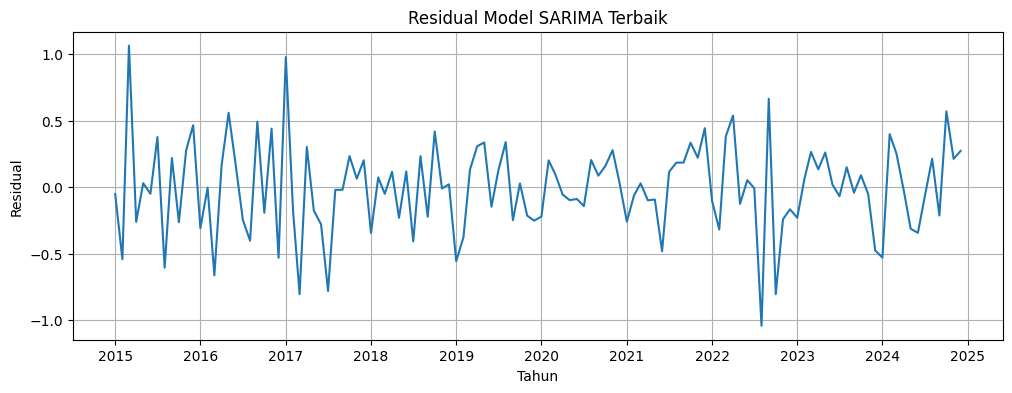

<Figure size 1000x400 with 0 Axes>

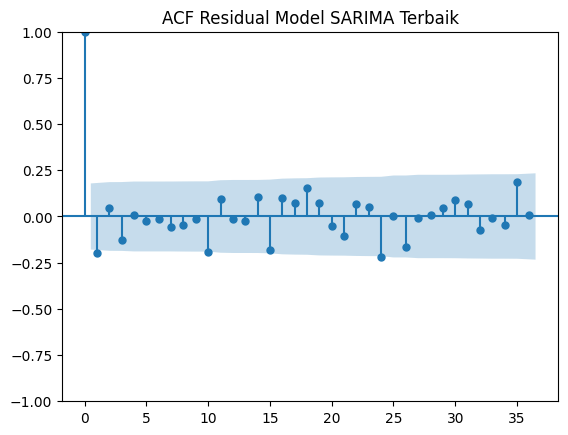

Ljung-Box Test:
      lb_stat  lb_pvalue
12  14.089848   0.295008
24  37.062309   0.043138
Shapiro-Wilk Test
Statistic: 0.987029922031234
p-value  : 0.30977646620028154


In [17]:
residual = best_fitted_train.resid.dropna()

plt.figure(figsize=(12, 4))
plt.plot(residual)
plt.title("Residual Model SARIMA Terbaik")
plt.xlabel("Tahun")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(residual, lags=36)
plt.title("ACF Residual Model SARIMA Terbaik")
plt.show()

lb = acorr_ljungbox(residual, lags=[12, 24], return_df=True)
print("Ljung-Box Test:")
print(lb)

shapiro_stat, shapiro_p = shapiro(residual)
print("Shapiro-Wilk Test")
print("Statistic:", shapiro_stat)
print("p-value  :", shapiro_p)

# Forecasting

In [18]:
final_model = SARIMAX(
    y,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fitted = final_model.fit(disp=False, maxiter=300)

forecast_2026 = final_fitted.get_forecast(steps=12)
forecast_mean = forecast_2026.predicted_mean
forecast_ci = forecast_2026.conf_int(alpha=0.05)

df_forecast = pd.DataFrame({
    "forecast": forecast_mean,
    "lower_95": forecast_ci.iloc[:, 0],
    "upper_95": forecast_ci.iloc[:, 1]
})

display(df_forecast)
df_forecast.to_csv("forecast_inflasi_2026_sarima_jatim.csv")

,forecast,lower_95,upper_95
2026-01-01,-0.096840,-0.717594,0.523913
2026-02-01,-0.180392,-0.802310,0.441527
2026-03-01,0.564661,-0.057739,1.187061
2026-04-01,0.263825,-0.388008,0.915657
2026-05-01,-0.336723,-1.064243,0.390797
2026-06-01,-0.120125,-0.934888,0.694639
2026-07-01,-0.020700,-0.911143,0.869742
2026-08-01,-0.274991,-1.228187,0.678204
2026-09-01,-0.022289,-1.030452,0.985874
2026-10-01,0.022933,-1.036475,1.082342


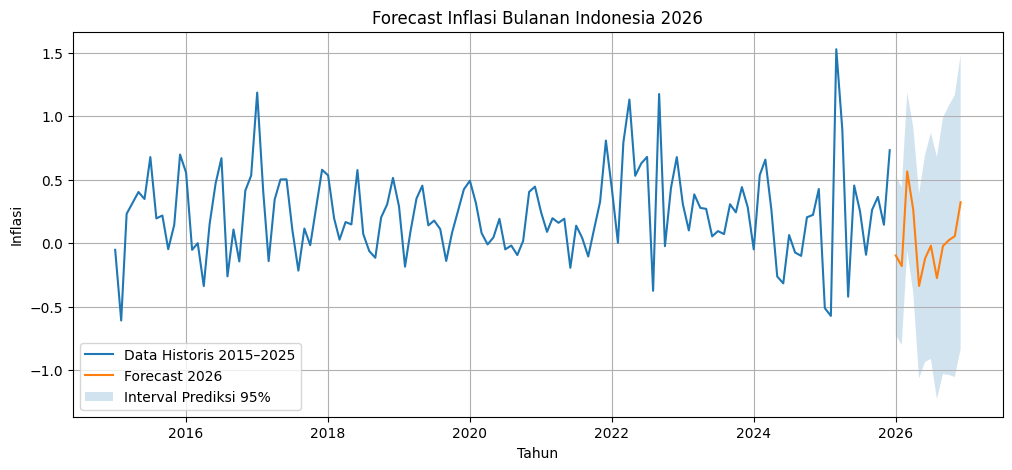

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(y.index, y, label="Data Historis 2015–2025")
plt.plot(df_forecast.index, df_forecast["forecast"], label="Forecast 2026")

plt.fill_between(
    df_forecast.index,
    df_forecast["lower_95"],
    df_forecast["upper_95"],
    alpha=0.2,
    label="Interval Prediksi 95%"
)

plt.title("Forecast Inflasi Bulanan Indonesia 2026")
plt.xlabel("Tahun")
plt.ylabel("Inflasi")
plt.legend()
plt.grid(True)
plt.show()